In [427]:

#Import bibliotek
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU, Bidirectional, Input
from keras.optimizers import SGD, Adam
import math
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from keras.losses import Huber

In [428]:
def plot_predictions(test,predicted):
  plt.plot(test, color='red',label='Real GOOGL Stock Price')
  plt.plot(predicted, color='blue', label='Predicted GOOGL Stock Price')
  plt.title('GOOGL Stock Price Prediction')
  plt.xlabel('Time')
  plt.ylabel('GOOGL Stock Price')
  plt.legend()
  plt.show()

In [429]:
def return_rmse(test, predicted):
  rmse = math.sqrt(mean_squared_error(test, predicted))
  print("-" * 30)
  print("Błąd średniokwadratowy modelu {:.2f}.".format(rmse))
  print("-" * 30)
def return_mae (test, predicted):
  mae = mean_absolute_error(test, predicted)
  mape = mean_absolute_percentage_error(test, predicted) * 100
  print("Średni błąd bezwzględny: {:.2f}.".format(mae))
  print("Średni błąd bezwzględny procentowy: {:.2f}%".format(mape))
  print("-"*30)

In [430]:
dataset=pd.read_csv('GOOGL_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,211.47,218.05,209.32,217.83,13137450,GOOGL
2006-01-04,222.17,224.70,220.09,222.84,15292353,GOOGL
2006-01-05,223.22,226.00,220.97,225.85,10815661,GOOGL
2006-01-06,228.66,235.49,226.85,233.06,17759521,GOOGL
2006-01-09,233.44,236.94,230.70,233.68,12795837,GOOGL


In [431]:
#training_set = dataset[:'2016'].iloc[:,1:2].values
#test_set = dataset['2017':].iloc[:,1:2].values

training_set = dataset[:'2016'][['Close']].values
test_set = dataset['2017':][['Close']].values

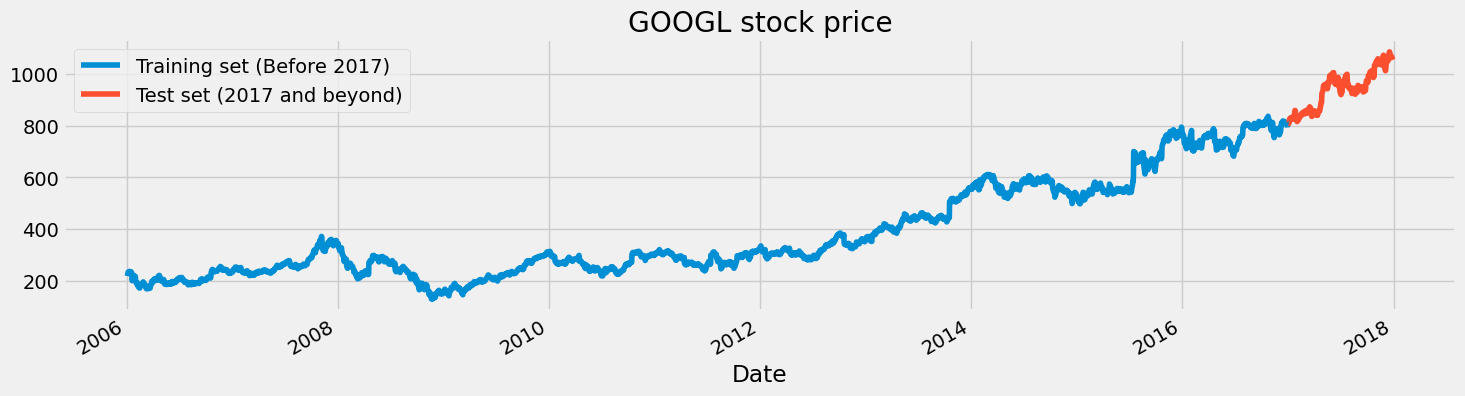

In [432]:
#dataset["High"][:'2016'].plot(figsize=(16,4),legend=True)
#dataset["High"]['2017':].plot(figsize=(16,4),legend=True)
#punkt D
dataset["Close"][:'2016'].plot(figsize=(16,4),legend=True)
dataset["Close"]['2017':].plot(figsize=(16,4),legend=True)

plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('GOOGL stock price')
plt.show()

In [433]:
sc = MinMaxScaler(feature_range=(0,1))
training_set_scaled = sc.fit_transform(training_set)

In [434]:
x_train = []
y_train = []
for i in range(60,2768):
  x_train.append(training_set_scaled[i-60:i,0])
  y_train.append(training_set_scaled[i,0])
x_train,y_train = np.array(x_train),np.array(y_train)

In [435]:
x_train = np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))

In [453]:
#Najlepsze znalezione ustawienie modelu


from keras.losses import MeanSquaredError, MeanAbsoluteError, Huber, LogCosh

regressor = Sequential()

#Zmienione warstwy po eksperymentach (punkt A)
regressor.add(Input(shape=(x_train.shape[1], 1)))

regressor.add(LSTM(units=32))
regressor.add(Dropout(0.1))
regressor.add(Dense(units=1))


#regressor.compile(optimizer='rmsprop',loss='mean_squared_error')
regressor.compile(optimizer=Adam(learning_rate=0.001),loss=LogCosh())

#regressor.fit(x_train,y_train, epochs=100, batch_size=32)

early_stop = EarlyStopping(monitor='val_loss',patience=25, restore_best_weights=True, verbose = 1)
regressor.fit(x_train,y_train, epochs=200, batch_size=32, validation_split=0.1, callbacks=[early_stop])

Epoch 1/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0081 - val_loss: 3.3360e-04
Epoch 2/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 8.1076e-04 - val_loss: 4.1429e-04
Epoch 3/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.2035e-04 - val_loss: 7.8712e-04
Epoch 4/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.7190e-04 - val_loss: 5.1314e-04
Epoch 5/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.8488e-04 - val_loss: 0.0011
Epoch 6/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 5.0871e-04 - val_loss: 3.6256e-04
Epoch 7/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.2304e-04 - val_loss: 3.1061e-04
Epoch 8/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.7566e-04 - val_loss: 3.9169e-04
Epoch 9/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.1554e-04 - val_loss: 2.6203e-04
Epoch 10/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.3678e-04 - val_loss: 5.4390e-04
Epoch 11/200
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 4.1487e-04 - val

G. Podaj według Ciebie najlepszą konfigurację dla predykcji. Uzasadnij.

**UZASADNIENIE MODELU**

Prostsza architektura z jedną warstwą LSTM lepiej generalizowała, podczas gdy większe modele częściej przeuczały się i gorzej odwzorowywały dane testowe.

Adam z learning_rate=0.001 zapewnił stabilniejsze uczenie, a LogCosh okazał się lepszym wyborem niż MSE, ponieważ jest mniej wrażliwy na większe odchylenia i jednocześnie dobrze reaguje na małe błędy.

Zastosowanie EarlyStopping z obserwacją val_loss pozwoliło kontrolować moment zakończenia uczenia na podstawie jakości predykcji dla danych walidacyjnych, dzięki czemu ocena modelu była bardziej miarodajna niż przy wykorzystaniu wyłącznie loss.

In [454]:
dataset_total = pd.concat((dataset["Close"][:'2016'],dataset["Close"]['2017':]),axis=0)
inputs = dataset_total[len(dataset_total)-len(test_set) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = sc.transform(inputs)

In [455]:
X_test = []
for i in range(60,311):
  X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


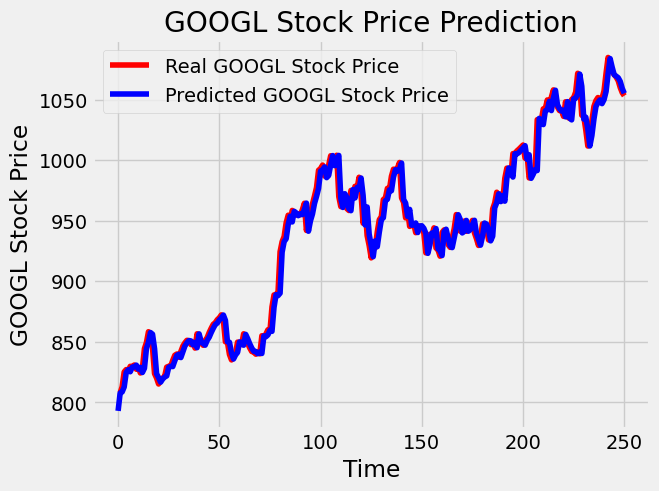

------------------------------
Błąd średniokwadratowy modelu 9.24.
------------------------------
Średni błąd bezwzględny: 6.63.
Średni błąd bezwzględny procentowy: 0.70%
------------------------------


In [456]:
plot_predictions(test_set,predicted_stock_price)
return_rmse(test_set,predicted_stock_price)
return_mae(test_set,predicted_stock_price)

F. Uzyskaj ostateczny błąd RMSE poniżej 2.0

Udało się uzyskać RMSE poniżej 9.5

ZADANIE 2

In [165]:

# Architektura z bramką GRU
regressorGRU = Sequential()

regressorGRU.add(Input(shape=(x_train.shape[1], 1)))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout (0.2))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout (0.2))

regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout (0.2))

regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout (0.2))

regressorGRU.add(Dense (units=1))

regressorGRU.compile(optimizer='rmsprop', loss='mean_squared_error')


regressorGRU.fit(x_train,y_train, epochs=50, batch_size=32)

#early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True)
#regressorGRU.fit(x_train, y_train, epochs=100, batch_size=32, callbacks=[early_stop])

Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0104
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0056
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0046
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0036
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0036
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0030
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0030
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0030
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0028
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0026
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0024
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0025
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0022
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0022
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0023
Epoc

In [170]:
X_test = []
for i in range(60,311):
  X_test.append(inputs[i-60:i,0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


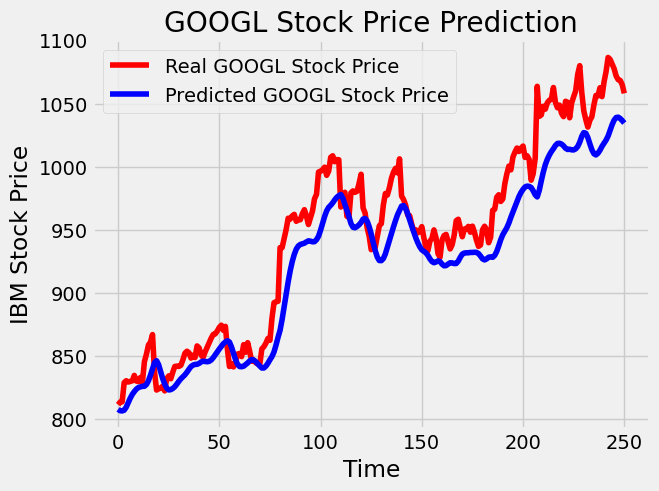

------------------------------
Błąd średniokwadratowy modelu 28.37.
------------------------------
Średni błąd bezwzględny: 23.59.
Średni błąd bezwzględny procentowy: 2.42%
------------------------------


In [171]:
plot_predictions(test_set,GRU_predicted_stock_price)
return_rmse(test_set,GRU_predicted_stock_price)
return_mae(test_set,GRU_predicted_stock_price)

Porównanie LSTM i GRU:
Brak zauważalnej/mierzalnej różnicy w czasie trenowania, wyniki bardzo zbliżone, lekko na korzyść GRU.

50 epok, brak early stopping, warstwy nie zmieniane.

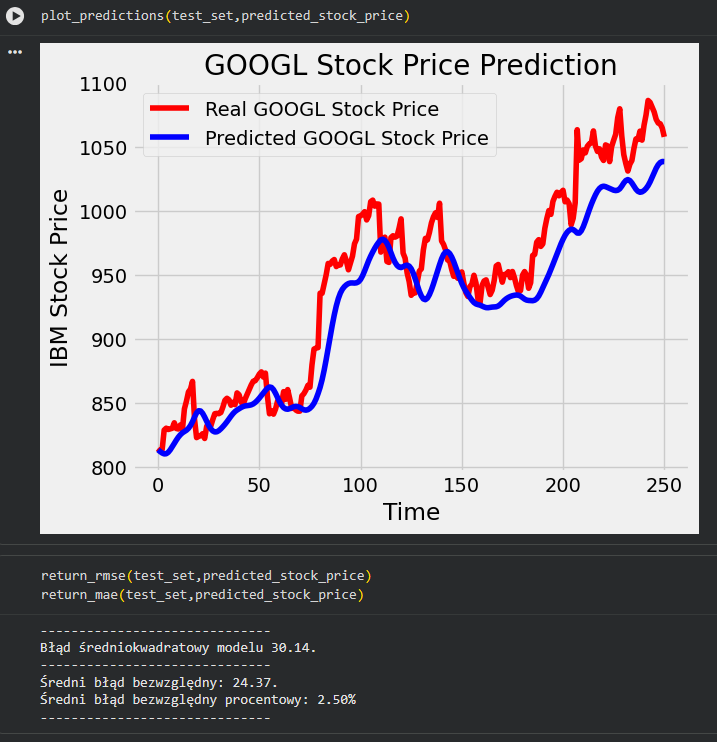

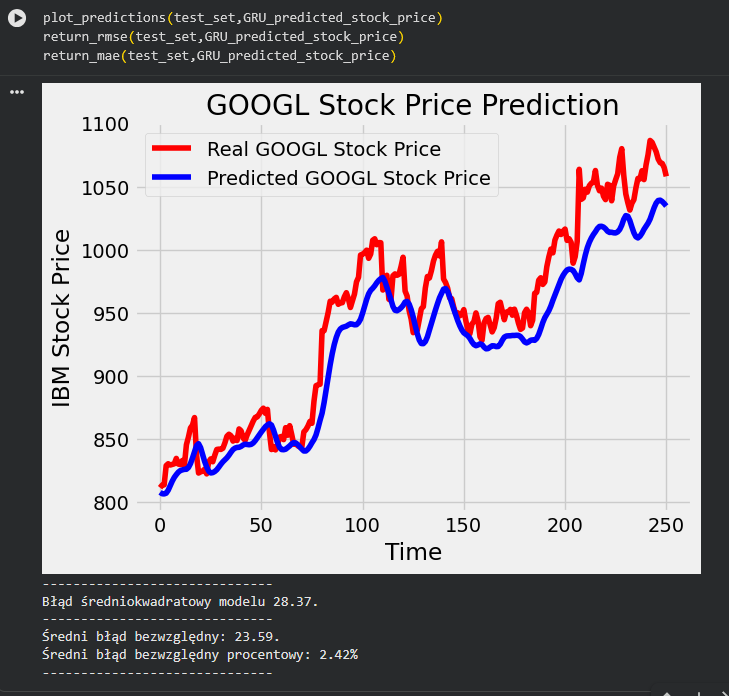

A. Poeksperymentuj z ilością jednostek LSTM

Duże uproszczenie modelu dało najlepsze rezultaty.

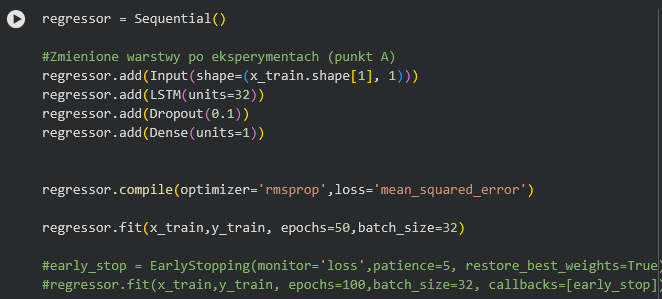


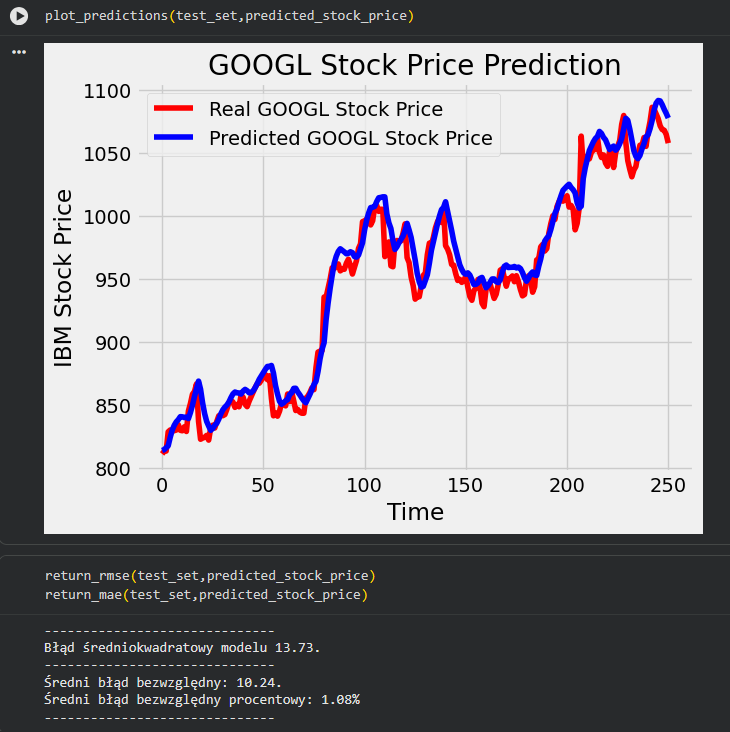

B. Przetestuj inne optymizatory - np. SGD , Adam, AdamW - porównaj wyniki

Bez zmian optymalizatora:

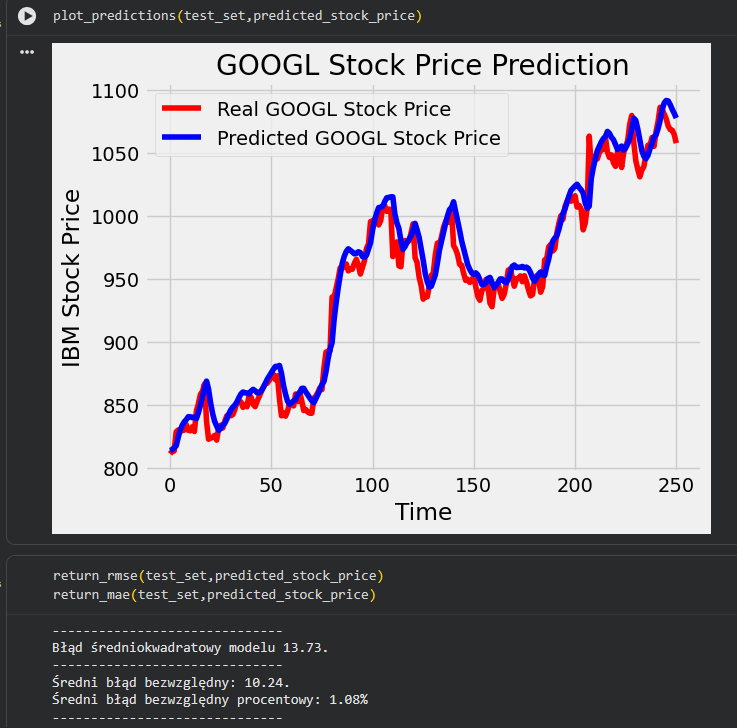

SGD:

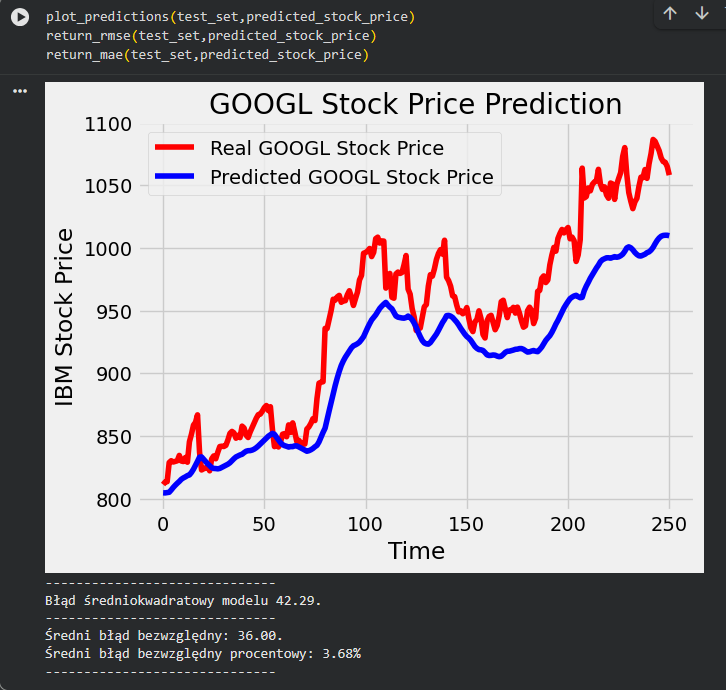

Adam:

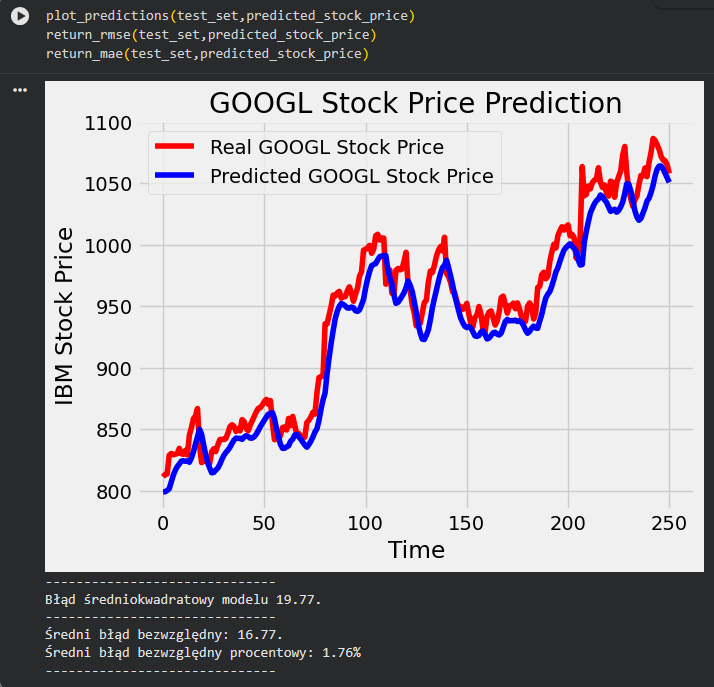

AdamW:

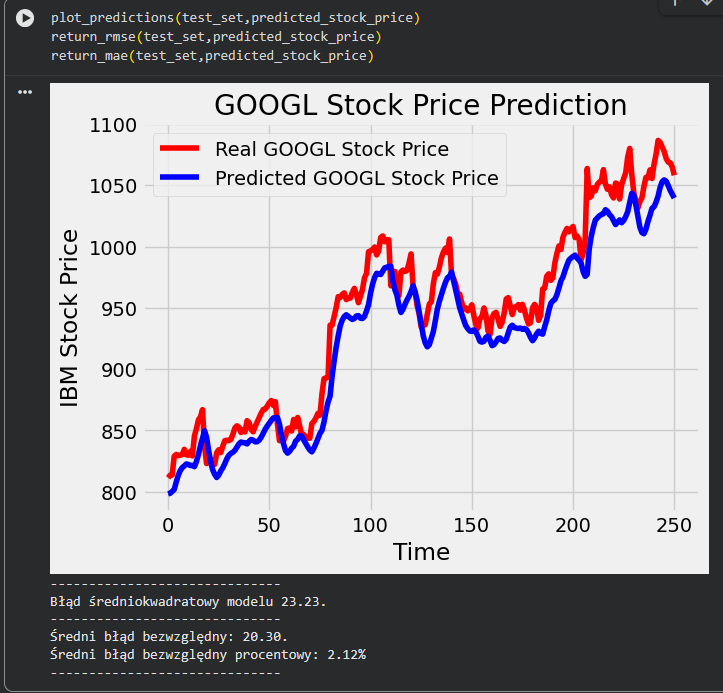


RMSprop dał najlepsze wyniki.

. Przetestuj inne funkcje straty: np. Mean Absolute Error, Huber, LogCosh lub inne
– porównaj wyniki (oczywiście należy zaimportować odpowiednie klasy).

Wyniki MAE:

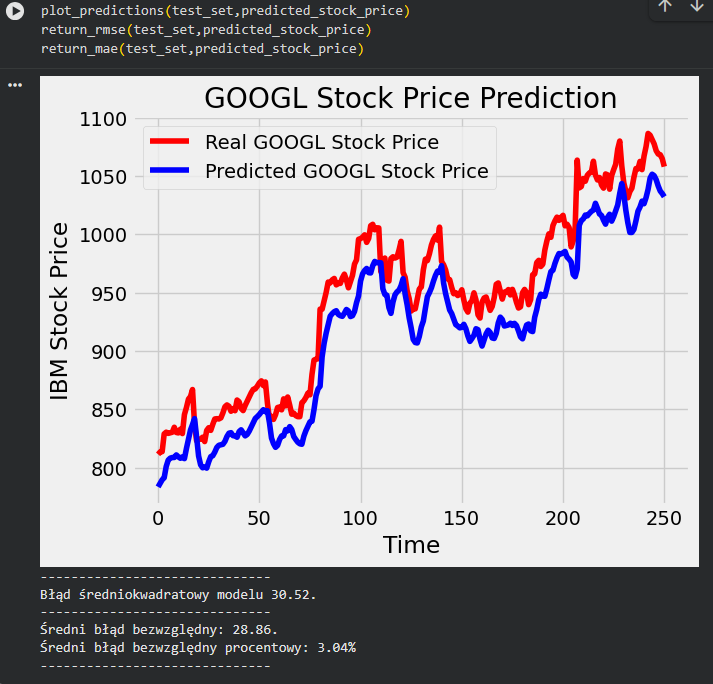

Wyniki Hubber:

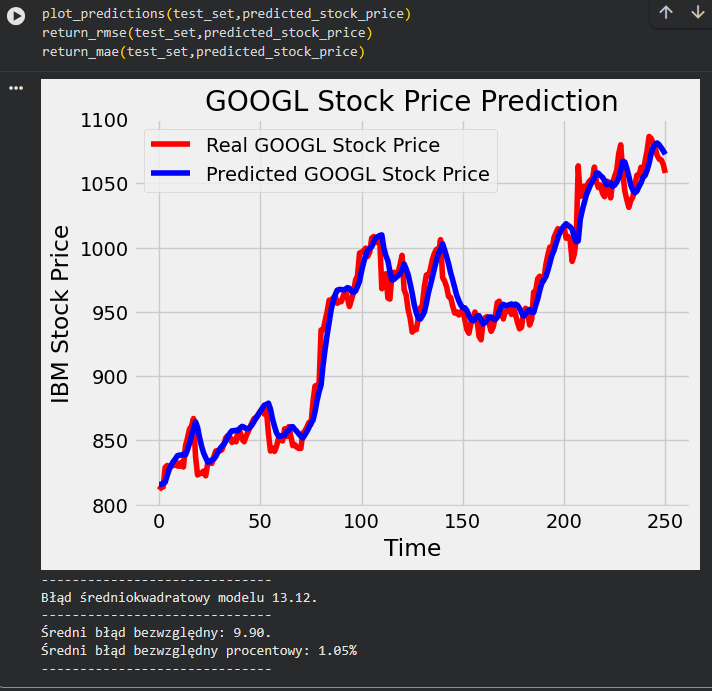

Wyniki LogCosh:
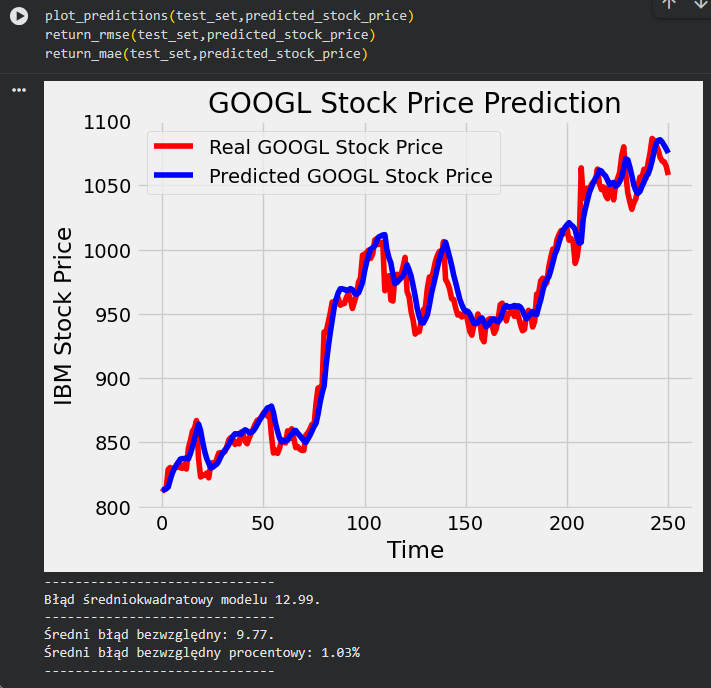

LogCosh dał najlepsze wyniki.

D. Zmień atrybut predykcji z „High” na „Close” i zaobserwuj różnice w dokładności.

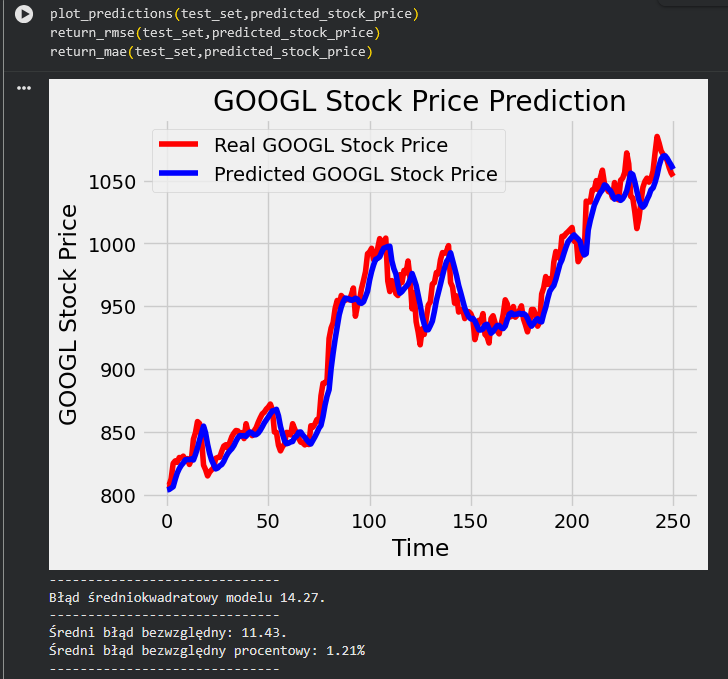

Brak znaczącej różnicy przy aktualnym modelu.

E. Przetestuj mechanizm Early Stopping (ustaw 100 epok) – sprawdź różnice w ilości
trenowanych epok z i bez tego mechanizmu. Zamiast „loss” obserwuj „val_loss”
dodając walidację. Jest to bardziej właściwe podejście.

Wynik bazowy - 100 epok bez early stopping:

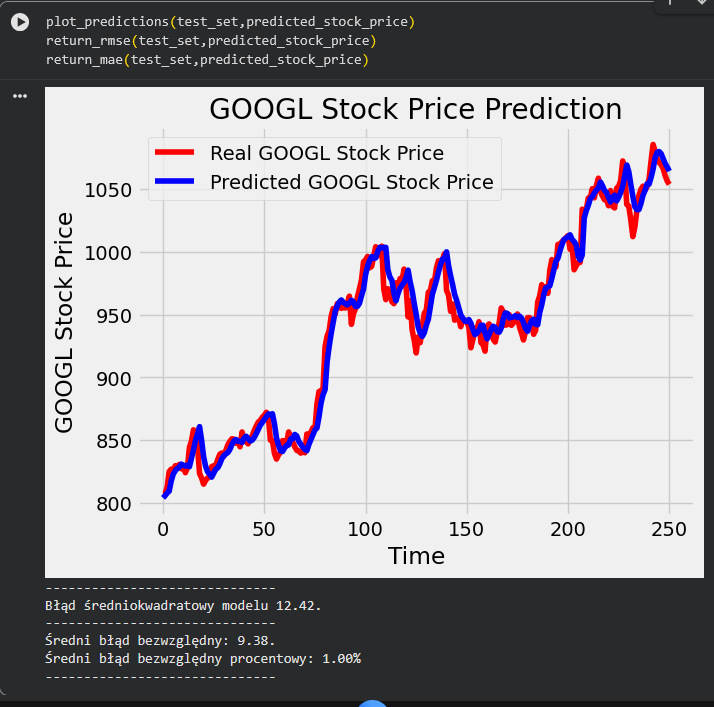

100 epok + Early stopping - wagi modelu z epoki 44:

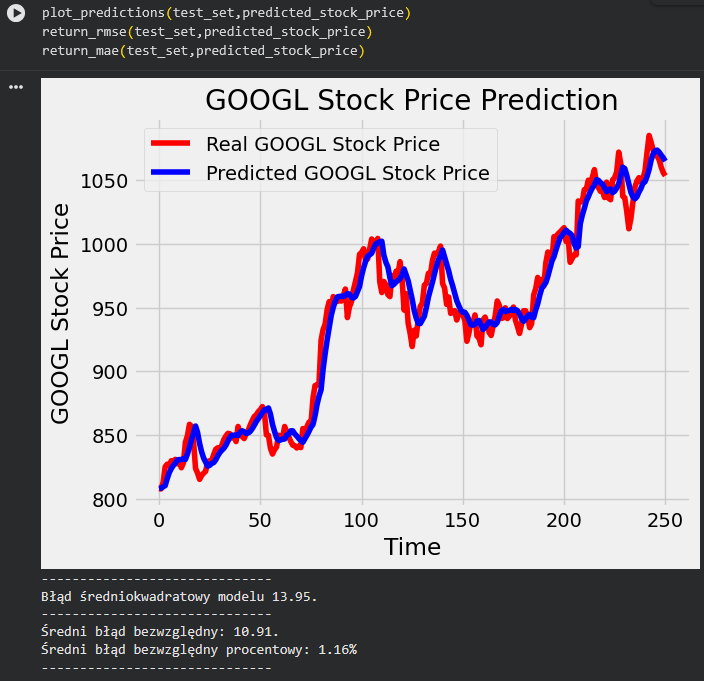